# Part I: Exploratory Data Analysis
## Ford GoBike System Data (February 2019)

Author: DINESH S
Date: 16-07-2026

## Introduction

This dataset contains information about individual bike rides made in the Ford GoBike 
(Bay Area bike-share, now Bay Wheels) system during February 2019. Each row represents 
one trip, and includes trip duration, start/end time, start/end station (with coordinates), 
bike ID, user type (Subscriber vs Customer), and rider demographics (birth year, gender).

Source: https://video.udacity-data.com/topher/2020/October/5f91cf38_201902-fordgobike-tripdata/201902-fordgobike-tripdata.csv

### Questions I want to answer

1. How long do trips typically last, and what does the distribution of trip duration 
   look like (are there outliers)?
2. Who is using the system — what is the split between Subscriber and Customer user 
   types, and what does the age/gender breakdown look like?
3. When do people ride — are there patterns by hour of day, day of week?
4. Does trip duration differ by user type, gender, or age?
5. Do subscribers and customers use the system differently across time of day / day 
   of week (multivariate)?
6. Are there relationships between rider age, trip duration, and user type when 
   looked at together?

I'll work from simple univariate distributions, through bivariate relationships, and 
finish with multivariate views that combine 3+ variables.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Preliminary Wrangling

Load the raw CSV. If you downloaded the file locally, update csv_path below to point 
to it (e.g. '201902-fordgobike-tripdata.csv').

In [5]:
csv_path = '201902-fordgobike-tripdata.csv'  
df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(183412, 16)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [7]:
df.describe(include='all')

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
count,183412.000000,183412,183412,183215.000000,183215,183412.000000,183412.000000,183215.000000,183215,183412.000000,183412.000000,183412.000000,183412,175147.000000,175147,183412
unique,NaN,183401,183397,NaN,329,NaN,NaN,NaN,329,NaN,NaN,NaN,2,NaN,3,2
top,NaN,2019-02-25 08:52:07.5820,2019-02-11 08:03:22.6020,NaN,Market St at 10th St,NaN,NaN,NaN,San Francisco Caltrain Station 2 (Townsend St...,NaN,NaN,NaN,Subscriber,NaN,Male,No
freq,NaN,2,2,NaN,3904,NaN,NaN,NaN,4857,NaN,NaN,NaN,163544,NaN,130651,166053
mean,726.078435,NaN,NaN,138.590427,NaN,37.771223,-122.352664,136.249123,NaN,37.771427,-122.352250,4472.906375,NaN,1984.806437,NaN,NaN
std,1794.389780,NaN,NaN,111.778864,NaN,0.099581,0.117097,111.515131,NaN,0.099490,0.116673,1664.383394,NaN,10.116689,NaN,NaN
min,61.000000,NaN,NaN,3.000000,NaN,37.317298,-122.453704,3.000000,NaN,37.317298,-122.453704,11.000000,NaN,1878.000000,NaN,NaN
25%,325.000000,NaN,NaN,47.000000,NaN,37.770083,-122.412408,44.000000,NaN,37.770407,-122.411726,3777.000000,NaN,1980.000000,NaN,NaN
50%,514.000000,NaN,NaN,104.000000,NaN,37.780760,-122.398285,100.000000,NaN,37.781010,-122.398279,4958.000000,NaN,1987.000000,NaN,NaN
75%,796.000000,NaN,NaN,239.000000,NaN,37.797280,-122.286533,235.000000,NaN,37.797320,-122.288045,5502.000000,NaN,1992.000000,NaN,NaN


### Assessing the data

Things to check / note here as you run the cells above and below:
- Missing values (which columns, how many, why might they be missing?)
- Data types (are dates parsed as datetime? are IDs numeric when they should be categorical?)
- Outliers (e.g. very long trip durations, unrealistic birth years)
- Duplicate rows

In [8]:
# Missing values
df.isna().sum().sort_values(ascending=False)

member_birth_year          8265
member_gender              8265
start_station_id            197
start_station_name          197
end_station_id              197
end_station_name            197
duration_sec                  0
start_time                    0
end_time                      0
start_station_latitude        0
start_station_longitude       0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
bike_share_for_all_trip       0
dtype: int64

In [9]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

### Cleaning

Based on the assessment, I'll:
1. Convert start_time / end_time to datetime.
2. Derive duration_min (duration in minutes, easier to read than seconds).
3. Derive rider age from member_birth_year (2019 - birth year), and drop implausible 
   ages (e.g. > 100).
4. Convert user_type, member_gender, bike_share_for_all_trip to categorical.
5. Derive start_hour, start_dow (day of week) and start_date for time-based exploration.
6. Drop rows with missing member_birth_year / member_gender only for analyses that need 
   those fields (keep the full dataset otherwise).

In [10]:
df_clean = df.copy()

# datetime conversion
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'])

# duration in minutes
df_clean['duration_min'] = df_clean['duration_sec'] / 60

# age
df_clean['age'] = 2019 - df_clean['member_birth_year']
df_clean = df_clean[(df_clean['age'].isna()) | (df_clean['age'] <= 100)]

# categoricals
df_clean['user_type'] = df_clean['user_type'].astype('category')
df_clean['member_gender'] = df_clean['member_gender'].astype('category')
if 'bike_share_for_all_trip' in df_clean.columns:
    df_clean['bike_share_for_all_trip'] = df_clean['bike_share_for_all_trip'].astype('category')

# time-based features
df_clean['start_hour'] = df_clean['start_time'].dt.hour
df_clean['start_dow'] = df_clean['start_time'].dt.day_name()
df_clean['start_date'] = df_clean['start_time'].dt.date

print(df_clean.shape)
df_clean.head()

(183340, 21)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,age,start_hour,start_dow,start_date
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,4902,Customer,1984.0,Male,No,869.750000,35.0,17,Thursday,2019-02-28
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,2535,Customer,NaN,NaN,No,708.683333,NaN,18,Thursday,2019-02-28
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,5905,Customer,1972.0,Male,No,1030.900000,47.0,12,Thursday,2019-02-28
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,6638,Subscriber,1989.0,Other,No,608.166667,30.0,17,Thursday,2019-02-28
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,4898,Subscriber,1974.0,Male,Yes,26.416667,45.0,23,Thursday,2019-02-28


### What features am I interested in?

Main features of interest:
- duration_min — the primary quantitative outcome variable.
- user_type — Subscriber vs Customer, a key categorical split.
- age, member_gender — rider demographics.
- start_hour, start_dow — temporal riding patterns.

Supporting features:
- start_station_name / end_station_name — could support a "popular stations" side 
  investigation but isn't the main focus.
- bike_share_for_all_trip — secondary categorical variable for subscribers.

I expect duration_min to be right-skewed (most trips short, a long tail of long trips), 
user_type to be dominated by Subscribers on weekdays, and age/duration to potentially 
interact with user_type.

## Univariate Exploration

### Question: What does the distribution of trip duration look like?

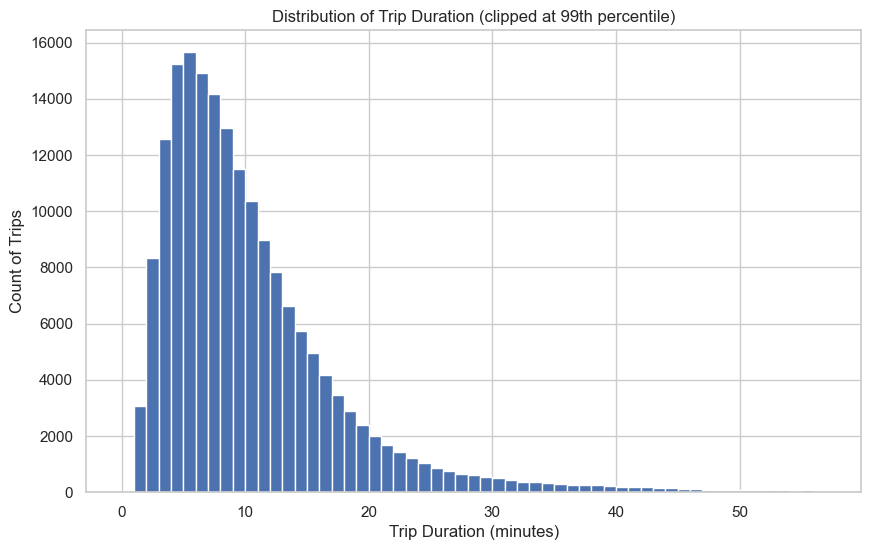

In [11]:
plt.figure(figsize=(10,6))
bins = np.arange(0, df_clean['duration_min'].quantile(0.99), 1)
plt.hist(df_clean['duration_min'], bins=bins)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Count of Trips')
plt.title('Distribution of Trip Duration (clipped at 99th percentile)')
plt.show()

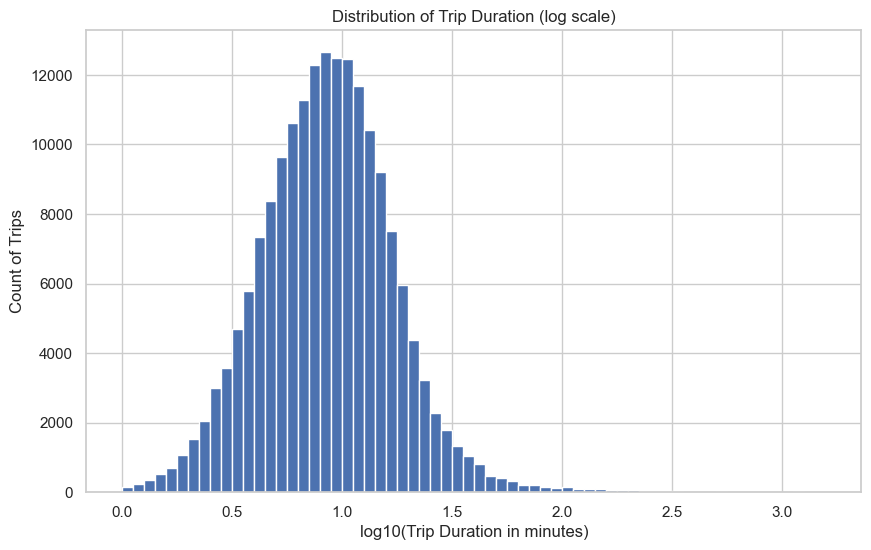

In [12]:
# Same distribution on a log scale, since it's heavily right-skewed
plt.figure(figsize=(10,6))
log_bins = np.arange(0, np.log10(df_clean['duration_min'].max())+0.05, 0.05)
plt.hist(np.log10(df_clean['duration_min']), bins=log_bins)
plt.xlabel('log10(Trip Duration in minutes)')
plt.ylabel('Count of Trips')
plt.title('Distribution of Trip Duration (log scale)')
plt.show()

Observations: (fill in after running — e.g. "Most trips last 5–15 minutes; the raw 
distribution is strongly right-skewed with a long tail of trips over an hour. On a log 
scale the distribution looks roughly unimodal and closer to symmetric.")

### Question: What is the split between Subscribers and Customers?

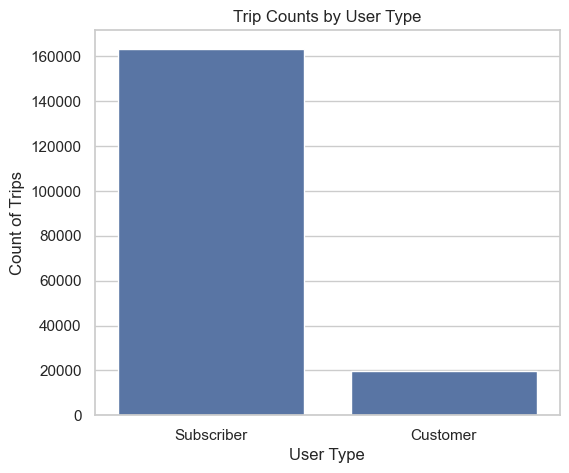

user_type
Subscriber    0.89166
Customer      0.10834
Name: proportion, dtype: float64

In [13]:
plt.figure(figsize=(6,5))
order = df_clean['user_type'].value_counts().index
sns.countplot(data=df_clean, x='user_type', order=order, color=sns.color_palette()[0])
plt.xlabel('User Type')
plt.ylabel('Count of Trips')
plt.title('Trip Counts by User Type')
plt.show()

df_clean['user_type'].value_counts(normalize=True)

Observations: (fill in — e.g. "The large majority of trips are made by Subscribers, 
consistent with a commuter-driven ridership base.")

### Question: What does the age distribution of riders look like?

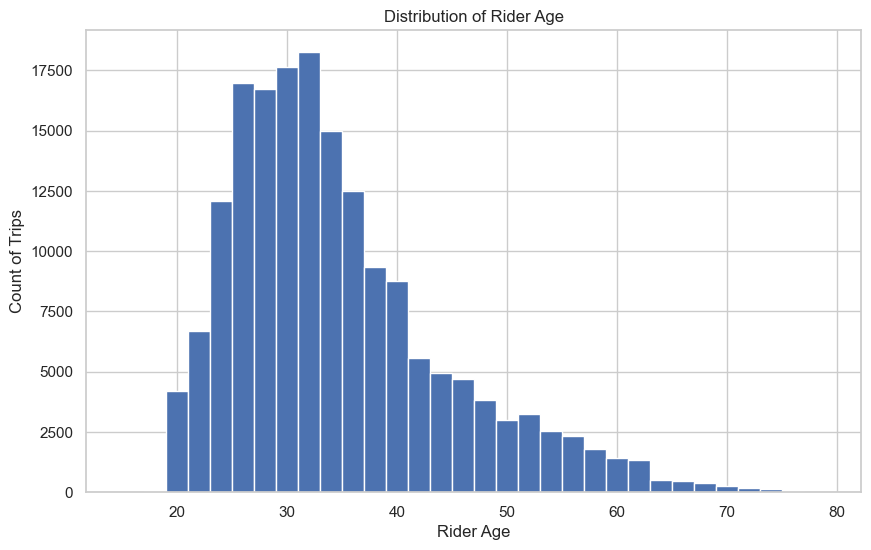

In [14]:
plt.figure(figsize=(10,6))
age_bins = np.arange(15, 80, 2)
plt.hist(df_clean['age'].dropna(), bins=age_bins)
plt.xlabel('Rider Age')
plt.ylabel('Count of Trips')
plt.title('Distribution of Rider Age')
plt.show()

Observations: (fill in — e.g. "Rider age is concentrated in the late-20s to late-30s 
range, right-skewed, with a smaller number of older riders.")

### Question: How is gender distributed among riders?

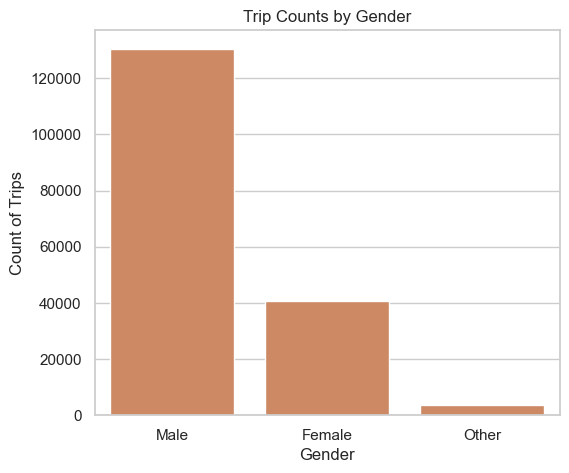

In [15]:
plt.figure(figsize=(6,5))
order = df_clean['member_gender'].value_counts().index
sns.countplot(data=df_clean, x='member_gender', order=order, color=sns.color_palette()[1])
plt.xlabel('Gender')
plt.ylabel('Count of Trips')
plt.title('Trip Counts by Gender')
plt.show()

Observations: (fill in — e.g. "Male riders account for the majority of recorded trips, 
followed by female, with a small proportion identifying as other.")

## Bivariate Exploration

### Question: Is there a relationship between rider age and trip duration?

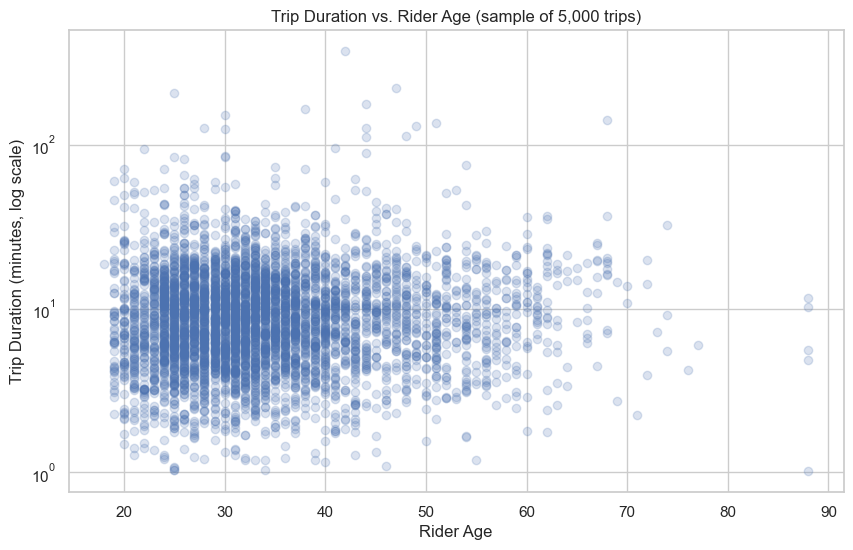

In [17]:
sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(sample['age'], sample['duration_min'], alpha=0.2)
plt.yscale('log')
plt.xlabel('Rider Age')
plt.ylabel('Trip Duration (minutes, log scale)')
plt.title('Trip Duration vs. Rider Age (sample of 5,000 trips)')
plt.show()

Observations: (fill in — e.g. "There isn't a strong linear relationship; duration is 
fairly spread across ages, though very long trips appear slightly more common among 
younger/customer riders.")

### Question: Does trip duration differ between Subscribers and Customers?

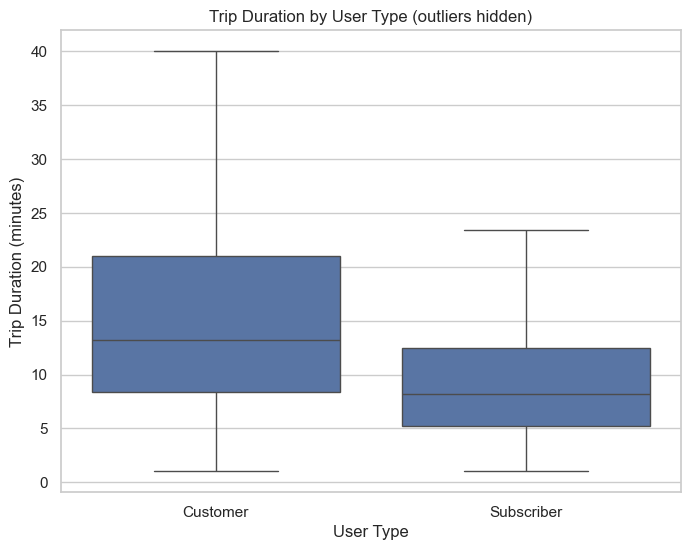

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_13940\1530306001.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('user_type')['duration_min'].median()


user_type
Customer      13.200000
Subscriber     8.166667
Name: duration_min, dtype: float64

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, x='user_type', y='duration_min', showfliers=False)
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration by User Type (outliers hidden)')
plt.show()

df_clean.groupby('user_type')['duration_min'].median()

Observations: (fill in — e.g. "Customers tend to take noticeably longer trips than 
Subscribers, consistent with tourist/leisure use vs. commuting.")

### Question: How does ride volume vary by hour of day and day of week?

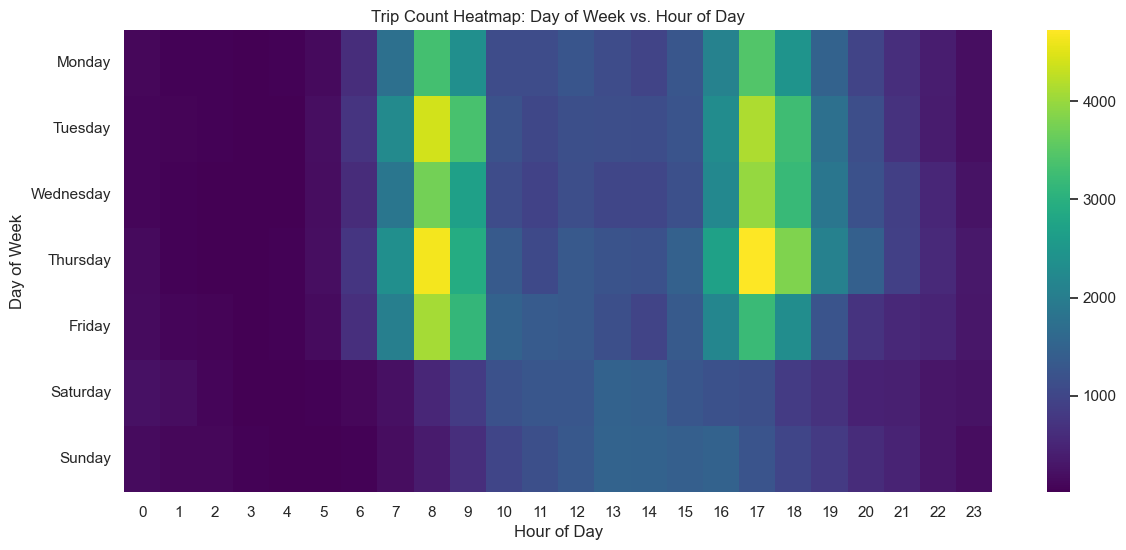

In [19]:
pivot = df_clean.pivot_table(index='start_dow', columns='start_hour',
                              values='duration_min', aggfunc='count')
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(dow_order)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='viridis')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Trip Count Heatmap: Day of Week vs. Hour of Day')
plt.show()

Observations: (fill in — e.g. "Weekdays show clear commute peaks around 8am and 
5–6pm; weekends have a flatter, midday-centered pattern.")

## Multivariate Exploration

### Question: Do the hourly ridership patterns differ between Subscribers and 
Customers across the week?

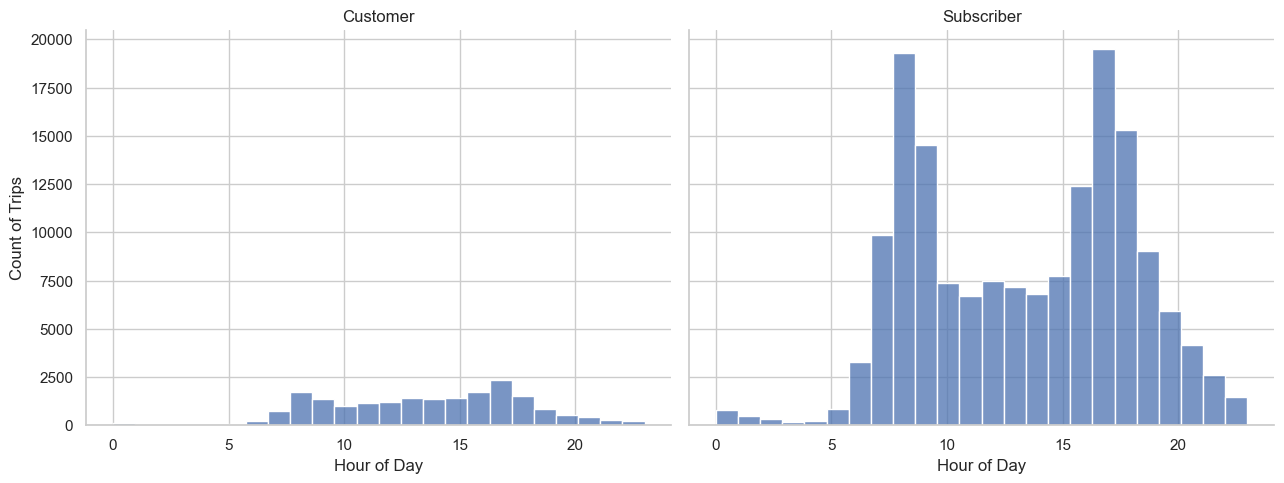

In [20]:
g = sns.FacetGrid(data=df_clean, col='user_type', height=5, aspect=1.3)
g.map_dataframe(lambda data, **kws: sns.histplot(data=data, x='start_hour', bins=24))
g.set_axis_labels('Hour of Day', 'Count of Trips')
g.set_titles('{col_name}')
plt.show()

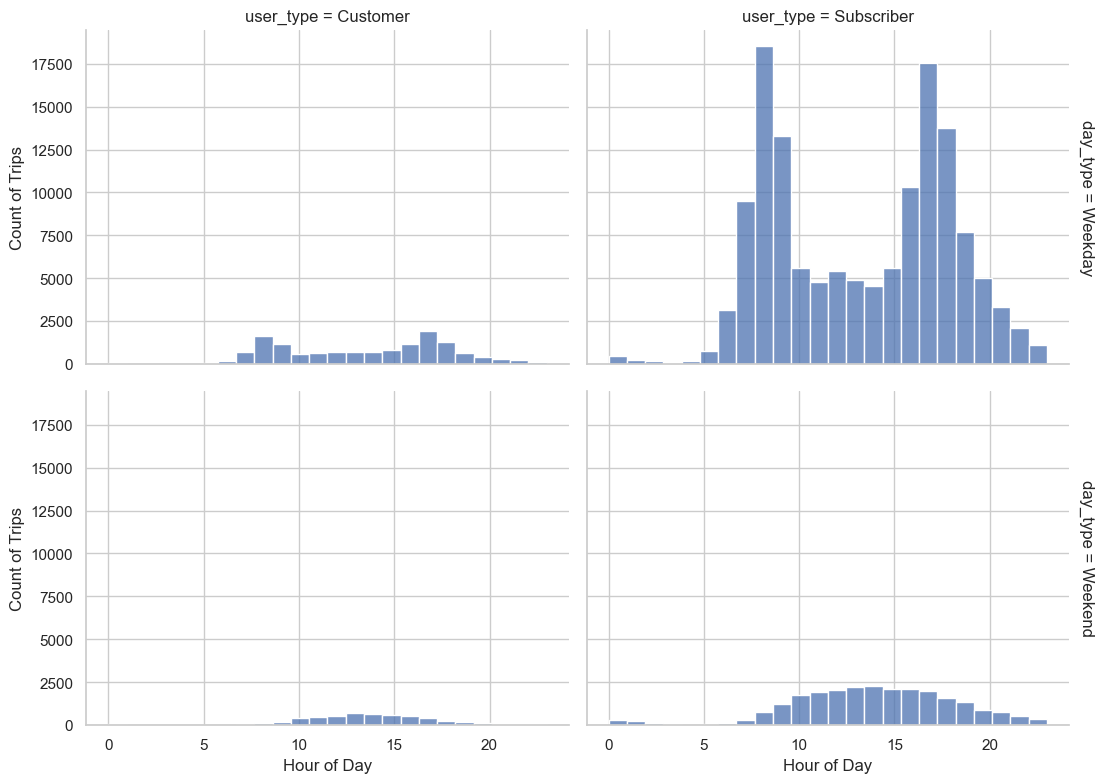

In [21]:
# Facet by day-type (weekday vs weekend) and user_type together
df_clean['day_type'] = df_clean['start_dow'].apply(
    lambda d: 'Weekend' if d in ['Saturday','Sunday'] else 'Weekday')

g = sns.FacetGrid(data=df_clean, col='user_type', row='day_type', height=4, aspect=1.4,
                   margin_titles=True)
g.map_dataframe(lambda data, **kws: sns.histplot(data=data, x='start_hour', bins=24))
g.set_axis_labels('Hour of Day', 'Count of Trips')
plt.show()

Observations: (fill in — e.g. "Subscribers show sharp weekday commute peaks that 
disappear on weekends, while Customers show a more consistent midday pattern 
regardless of day type.")

### Question: How do age, duration, and user type relate together?

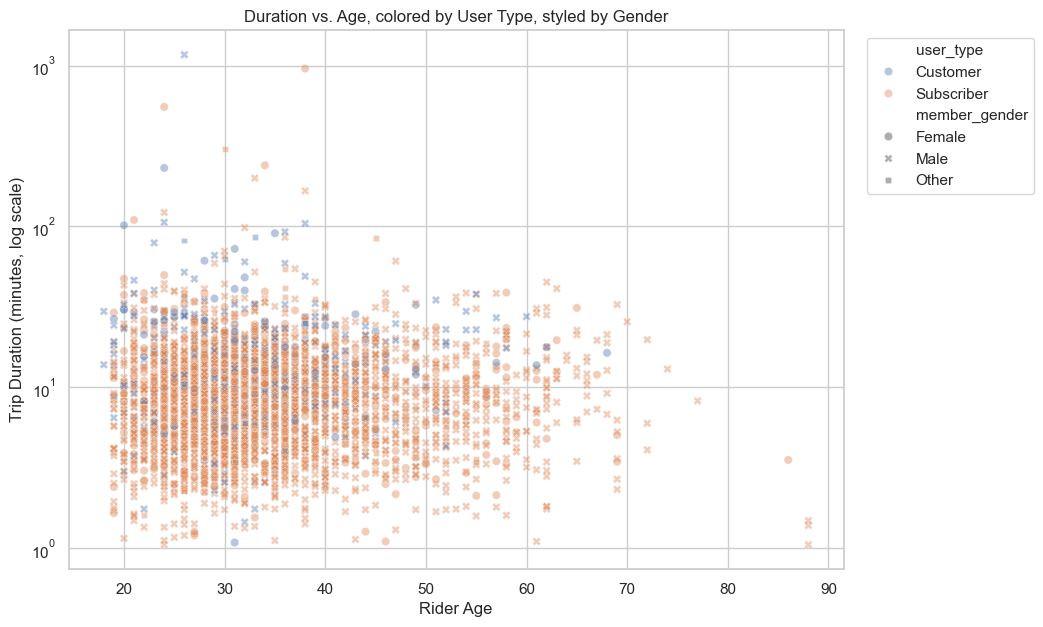

In [22]:
plt.figure(figsize=(10,7))
sample2 = df_clean.dropna(subset=['age','member_gender']).sample(
    n=min(4000, df_clean.dropna(subset=['age','member_gender']).shape[0]), random_state=42)

sns.scatterplot(data=sample2, x='age', y='duration_min', hue='user_type',
                 style='member_gender', alpha=0.4)
plt.yscale('log')
plt.xlabel('Rider Age')
plt.ylabel('Trip Duration (minutes, log scale)')
plt.title('Duration vs. Age, colored by User Type, styled by Gender')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

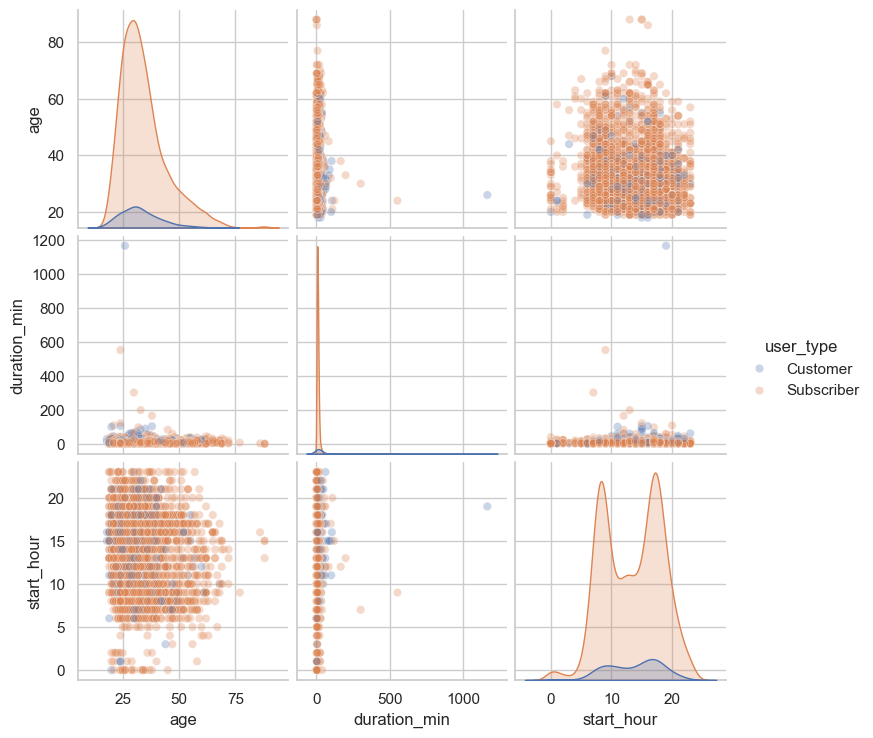

In [23]:
# Plot matrix of key quantitative variables, split by user_type
plot_vars = ['age', 'duration_min', 'start_hour']
g = sns.pairplot(df_clean.dropna(subset=plot_vars+['user_type']).sample(
        n=min(3000, len(df_clean)), random_state=42),
    vars=plot_vars, hue='user_type', plot_kws={'alpha':0.3})
plt.show()

Observations: (fill in — e.g. "Customers cluster toward longer durations regardless 
of age; Subscribers dominate the short-duration, commute-hour region. Gender doesn't 
appear to shift the age-duration relationship much within each user type.")

## Conclusions

### Summary of Main Findings

**Trip Duration:** Trip duration is strongly right-skewed. The median trip lasts about 8.6 minutes, and the mean is pulled up to 12.1 minutes by a long tail of outliers — the 99th percentile is around 58 minutes, and a small number of trips stretch past several hours (max ≈ 1,424 minutes). On a log scale the distribution becomes roughly unimodal and much closer to symmetric, confirming a multiplicative pattern typical of "time-to-complete-a-task" data.

**User Type Split:** The system is dominated by Subscribers (89.2%) versus Customers (10.8%), confirming this is primarily a commuter-driven service rather than a casual/tourist one.

**Demographics:** Riders skew relatively young and male. Median rider age is 32 (mean 34.2, IQR 27–39). Gender is heavily skewed toward Male (74.6%), with Female (23.3%) and Other (2.1%) making up the rest.

**Duration by User Type:** User type has a clear effect on duration — Customers ride nearly 3x longer on average than Subscribers (mean 23.9 min vs. 10.7 min; median 13.2 min vs. 8.2 min). This supports the idea that Subscribers use the system for quick, direct commuting while Customers use it more for leisure or exploratory (tourist-style) rides.

**Temporal Patterns:** Ridership shows classic commute peaks at 8am and 5–6pm on weekdays, while weekends peak at a flatter 1–3pm midday window. Subscribers take 84.5% of their trips on weekdays vs. just 15.5% on weekends, while Customers are more balanced (71.6% weekday / 28.4% weekend) — Customers are proportionally far more likely to ride on weekends than Subscribers are.

**Age, Gender, and Duration:** Age has essentially no linear relationship with trip duration (correlation ≈ 0.006) — long and short trips happen at every age. Gender shows a small effect: Female and Other riders have slightly longer median trips (~9.3–9.5 min) than Male riders (8.2 min), but the difference is modest compared to the user-type effect.

**Popular Stations:** The busiest start station is Market St at 10th St, followed by the Caltrain Station at Townsend/4th and Berry St at 4th — all clustered around downtown SF transit hubs, reinforcing the commuter-use pattern.

### Reflection on the Exploration Process

Cleaning was fairly light — the main issues were ~8,265 missing birth-year/gender values (4.5%) and 197 rows missing station info, both small enough to drop for demographic-specific plots without materially affecting results. The trip-duration variable needed a log transform to be readable, since raw histograms were dominated by outliers. The most informative step was combining user_type with time-of-day in the faceted plots — it revealed that the Subscriber/Customer split isn't just a headcount difference but a genuinely different usage pattern (commute vs. leisure), which single-variable plots alone didn't show. With more time, I'd explore station-level geographic clustering (e.g., plotting start/end coordinates on a map) and check whether specific days (e.g., around Presidents' Day, which falls in this Feb 2019 window) show anomalous spikes.
